<a href="https://colab.research.google.com/github/rubbiya/LinearRegression_assignment/blob/main/train%2C_test_and_split_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

In [7]:
df = pd.read_csv("/content/drive/MyDrive/student_performance_dataset-selected-columns.csv")

In [8]:
df

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1
2,2,16,Female,Urban,4.3,7,54,57,4.3,1
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0
4,4,17,Female,Urban,4.1,3,100,81,2.6,0
...,...,...,...,...,...,...,...,...,...,...
2995,2995,22,Female,Rural,2.4,0,40,83,1.0,0
2996,2996,19,Female,Urban,5.2,7,94,100,1.4,0
2997,2997,23,Female,Rural,5.9,2,41,86,5.4,1
2998,2998,17,Male,Urban,3.9,1,92,96,2.8,1


In [9]:
df.deep_work_sessions.median()

4.0

In [10]:
df.deep_work_sessions.fillna(4, inplace= True)
df

/tmp/ipykernel_8563/2318014033.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.deep_work_sessions.fillna(4, inplace= True)


,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1
2,2,16,Female,Urban,4.3,7,54,57,4.3,1
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0
4,4,17,Female,Urban,4.1,3,100,81,2.6,0
...,...,...,...,...,...,...,...,...,...,...
2995,2995,22,Female,Rural,2.4,0,40,83,1.0,0
2996,2996,19,Female,Urban,5.2,7,94,100,1.4,0
2997,2997,23,Female,Rural,5.9,2,41,86,5.4,1
2998,2998,17,Male,Urban,3.9,1,92,96,2.8,1


In [33]:
lr = linear_model.LinearRegression()
lr.fit(df[['age', 'study_hours_per_day', 'assignment_completion_rate']], df.study_hours_per_day)


LinearRegression()

In [34]:
lr.coef_

array([1.46013108e-17, 1.00000000e+00, 0.00000000e+00])

In [35]:
lr.intercept_

np.float64(-1.3322676295501878e-15)

In [36]:
lr.predict([[23,7,83]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7.])

In [18]:
predicted = -0.00278116*23+ -0.01502558*7+  0.00044733*83 + 4.0611061013845955
print(predicted)

3.9290887513845956


In [43]:
lr.score(df[['age', 'study_hours_per_day', 'assignment_completion_rate']], df.study_hours_per_day)

1.0

In [37]:
import pickle
with open('model_pickle', 'wb') as f:
  pickle.dump(lr, f)

In [38]:
import joblib
with open('model_joblib', 'wb') as f:
  joblib.dump(lr, f)

In [39]:
import joblib
lr2=joblib.load('model_joblib')

In [40]:
lr2.predict([[23,7,83]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7.])

In [41]:
import joblib
lr3=joblib.load('model_joblib')

In [42]:
lr3.predict([[23,7,83]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7.])

In [44]:
x = df[['age', 'study_hours_per_day', 'assignment_completion_rate']]
y = df.study_hours_per_day


In [45]:
x

,age,study_hours_per_day,assignment_completion_rate
0,21,3.2,100
1,19,3.9,46
2,16,4.3,54
3,19,5.3,78
4,17,4.1,100
...,...,...,...
2995,22,2.4,40
2996,19,5.2,94
2997,23,5.9,41
2998,17,3.9,92


In [46]:
y

,study_hours_per_day
0,3.2
1,3.9
2,4.3
3,5.3
4,4.1
...,...
2995,2.4
2996,5.2
2997,5.9
2998,3.9


In [47]:
from sklearn import model_selection
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=0.2)

In [48]:
x_train

,age,study_hours_per_day,assignment_completion_rate
2932,15,3.9,79
1774,19,4.4,85
647,19,2.9,87
290,15,4.0,47
213,16,4.2,46
...,...,...,...
1812,21,3.0,66
1449,23,3.9,54
520,18,4.7,68
2075,17,3.5,83


In [49]:
x_test

,age,study_hours_per_day,assignment_completion_rate
2556,20,3.3,75
703,15,5.0,68
2499,18,6.9,41
1604,20,4.8,82
40,16,3.5,71
...,...,...,...
1753,22,4.5,67
861,22,2.9,71
1470,20,2.9,76
1352,19,4.3,62


In [50]:
y_train

,study_hours_per_day
2932,3.9
1774,4.4
647,2.9
290,4.0
213,4.2
...,...
1812,3.0
1449,3.9
520,4.7
2075,3.5


In [51]:
y_test

,study_hours_per_day
2556,3.3
703,5.0
2499,6.9
1604,4.8
40,3.5
...,...
1753,4.5
861,2.9
1470,2.9
1352,4.3


In [52]:
len(x_train)

2400

In [53]:
len(y_train)

2400

In [54]:
len(x_test)

600

In [55]:
from sklearn import linear_model
lr = linear_model.LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [56]:
lr.coef_

array([1.43666425e-17, 1.00000000e+00, 0.00000000e+00])

In [57]:
lr.intercept_

np.float64(-3.552713678800501e-15)

In [58]:
lr.predict(x_test)

array([3.3, 5. , 6.9, 4.8, 3.5, 4.6, 5.1, 2.3, 2.5, 7.4, 4.4, 1.1, 5.4,
       4. , 5.3, 1. , 2.9, 3.6, 4.1, 5.5, 4.7, 5.1, 5. , 5.1, 2.8, 4.8,
       5.7, 2.6, 5. , 4.4, 3.2, 6.4, 6. , 2.6, 3.8, 4.5, 4.9, 1.7, 6.2,
       5.4, 4.3, 3.6, 5.3, 4.3, 1.4, 5.6, 2.9, 5. , 3.4, 5.8, 2.8, 5.2,
       4.5, 2.9, 5.6, 3.5, 2.5, 4.4, 6.3, 4.2, 5.1, 3.7, 4.3, 3.1, 6.5,
       4.5, 4.8, 4.6, 4.8, 2.5, 4.5, 2.2, 3.3, 4.7, 7.6, 3.6, 2.1, 4.7,
       6. , 2.7, 5.1, 1.7, 4.6, 3.3, 4.9, 3.4, 0.5, 3.9, 4.4, 3.7, 2.8,
       1.5, 5.9, 3.5, 4.1, 3.5, 5.9, 3.1, 3.3, 2.3, 3.9, 0.5, 4.7, 3.1,
       3.2, 5.4, 0.6, 5.9, 4.2, 5. , 3. , 4.6, 4.7, 1.2, 2.3, 4.8, 4.6,
       3.6, 3.4, 7.9, 4.6, 4.4, 4.4, 3.8, 1.8, 2.6, 4.7, 7.2, 4.7, 3.4,
       4.8, 4.2, 2.4, 4.4, 2.1, 3.4, 2.3, 0.5, 2.6, 3.5, 3.9, 4.3, 1. ,
       5.9, 2.6, 4.4, 4.4, 4.5, 1.5, 3.5, 4.7, 3.8, 5.9, 1.3, 4.2, 6.9,
       2.9, 5.7, 3.9, 3.4, 4.2, 5.8, 1.5, 2.5, 3.9, 4. , 3.4, 6.6, 2.1,
       0.7, 4.6, 2.4, 5.5, 1.2, 3.8, 2.4, 1.3, 4.8, 5.5, 3. , 4.

In [60]:
lr.score(x_test, y_test)

1.0

In [61]:
##PIE_CHART##

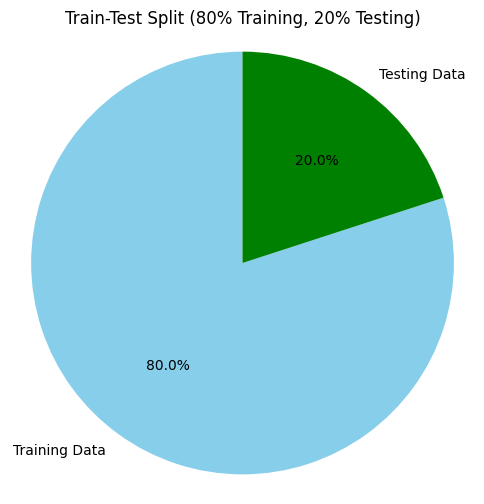

In [67]:
import matplotlib.pyplot as plt

labels = ['Training Data', 'Testing Data']
sizes = [2400,600]
colors = ['skyblue', 'green']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Train-Test Split (80% Training, 20% Testing)')
plt.axis('equal')   # Makes the pie chart circular
plt.show()